최종 모형 변수 : 64개
Statista 지표  : 76개 행

[COMPONENT 1] JSD 계산 중...
  변수 수           : 64개
  JSD 평균          : 0.0441
  1 - JSD_mean      : 0.9559  → COMPONENT 1

  [JSD 상위 10 — 분포 차이 큰 변수]
 variable  n_bins      jsd  sim_jsd
AL012G011       4 0.371490 0.628510
U81306010       5 0.329035 0.670965
L10220800       2 0.120457 0.879543
L10210800       2 0.119854 0.880146
AL012G019       4 0.106690 0.893310
U81305010       5 0.091739 0.908261
L90216300       2 0.089634 0.910366
L90210300       2 0.081681 0.918319
C1Z001373       5 0.057325 0.942675
L90210200       2 0.055133 0.944867

[COMPONENT 2] Spearman ρ 계산 중...
  Spearman ρ        : 0.8896
  |ρ|               : 0.8896  → COMPONENT 2
  p-value           : 0.0000
  ※ 인도네시아 순위 프록시 — 민감도 분석 대상

[COMPONENT 3] CosSim 계산 중...
  CosSim 입력 지표 수 : 34개 (문자열 행 제거 후)
  CosSim            : 0.9485  → COMPONENT 3

  [사용된 지표 카테고리]
category
eCommerce           19
Health               8
Country Overview     4
Economics            2
Tourism              1

  

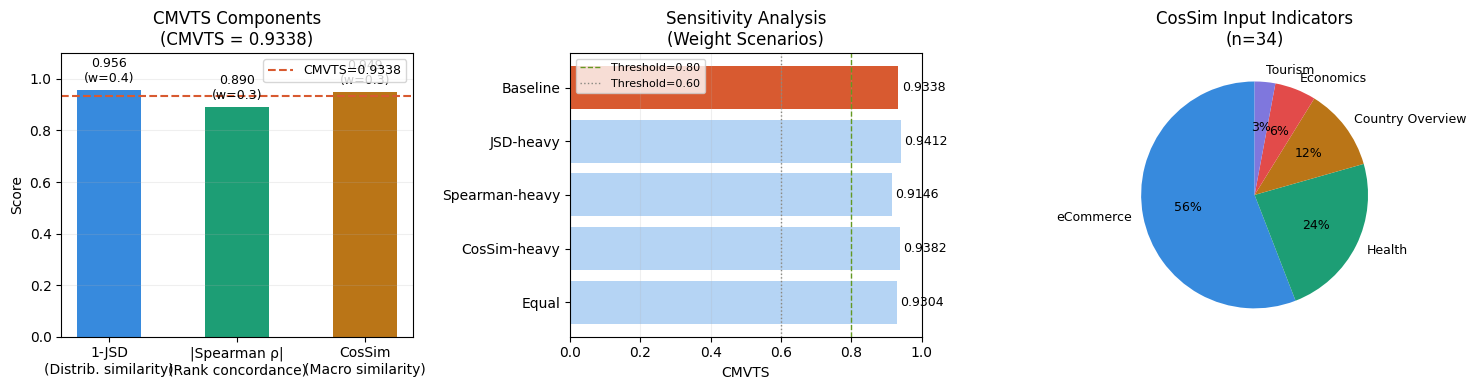


저장 완료:
  outputs/tables/04_cmvts_results.csv
  outputs/tables/04_sensitivity.csv
  outputs/tables/04_jsd_by_variable.csv
  outputs/figures/04_cmvts_results.png

→ 05_indonesia_scorecard_draft.ipynb 진행


In [4]:
# ============================================================
# 04_cmvts_calculation
# Cross-Market Variable Transferability Score (CMVTS) 산출
# CMVTS = w1*(1-JSD_mean) + w2*|ρ| + w3*CosSim
# ============================================================

# %% [1] 라이브러리
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib
import warnings
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# %% [2] 이전 결과 로드
with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

iv_selected  = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
final_vars   = pd.read_csv('outputs/tables/03_final_vars.csv')['variable'].tolist()
statista_df  = pd.read_csv('data/indonesia_korea_statistics.csv')

print(f"최종 모형 변수 : {len(final_vars)}개")
print(f"Statista 지표  : {len(statista_df)}개 행")

# %% [3] ── COMPONENT 1: JSD ──────────────────────────────────
# Jensen-Shannon Divergence: 변수별 WoE bin 분포 유사도
# 한국 분포: AI Hub WoE bins의 good 비율 분포
# 인도네시아 분포: 데이터 부재 → 균등분포 가정 (sensitivity 대상)

print("\n[COMPONENT 1] JSD 계산 중...")

def get_good_dist(bin_df):
    """WoE bin에서 good 비율 분포 추출"""
    # scorecardpy 버전별 컬럼명 대응
    good_col = 'good'   if 'good'   in bin_df.columns else 'count_distr'
    bad_col  = 'bad'    if 'bad'    in bin_df.columns else None

    if bad_col and bad_col in bin_df.columns:
        total = bin_df[good_col] + bin_df[bad_col]
        good_rate = bin_df[good_col] / total.replace(0, np.nan)
    else:
        good_rate = bin_df[good_col]

    dist = good_rate.dropna().values
    dist = np.where(dist <= 0, 1e-6, dist)
    return dist / dist.sum()   # 정규화

jsd_results = []
for var in final_vars:
    if var not in bins_all:
        continue
    bin_df = bins_all[var]

    # 한국 분포
    korea_dist = get_good_dist(bin_df)
    n_bins = len(korea_dist)

    # 인도네시아 프록시: 균등분포
    id_dist = np.ones(n_bins) / n_bins

    # JSD (scipy: 0=동일, 1=완전 다름)
    jsd_val = jensenshannon(korea_dist, id_dist, base=2)

    jsd_results.append({
        'variable' : var,
        'n_bins'   : n_bins,
        'jsd'      : round(jsd_val, 6),
        'sim_jsd'  : round(1 - jsd_val, 6)   # 유사도로 변환
    })

jsd_df = pd.DataFrame(jsd_results)
jsd_mean   = jsd_df['jsd'].mean()
sim1_jsd   = 1 - jsd_mean

print(f"  변수 수           : {len(jsd_df)}개")
print(f"  JSD 평균          : {jsd_mean:.4f}")
print(f"  1 - JSD_mean      : {sim1_jsd:.4f}  → COMPONENT 1")
print(f"\n  [JSD 상위 10 — 분포 차이 큰 변수]")
print(jsd_df.nlargest(10,'jsd')[['variable','n_bins','jsd','sim_jsd']].to_string(index=False))

# %% [4] ── COMPONENT 2: Spearman ρ ───────────────────────────
# 변수 중요도 순위 일치도
# 한국: IV 순위 (AI Hub)
# 인도네시아: 균등 순위 가정 (11번 파일 PK 불일치로 실측 불가)
# → 민감도 분석 대상으로 명시

print("\n[COMPONENT 2] Spearman ρ 계산 중...")

# 한국 IV 순위
iv_df = iv_selected[iv_selected['variable'].isin(final_vars)].copy()
iv_df = iv_df.sort_values('iv', ascending=False).reset_index(drop=True)
iv_df['rank_korea'] = iv_df.index + 1

# 인도네시아 IV 순위 프록시
# 연구기획서 Table 기준 11개 공통변수의 상대 순위를 참조
# 개인CB 내 매핑 가능 변수만 부분 순위 부여, 나머지 균등 처리
KNOWN_ID_RANK = {
    'U81201010': 1,   # 자산소득평가지수 — 보고서 IV 1위
    'U81202010': 2,   # 순자산평가금액
    'U81203010': 3,   # 총자산평가금액 구간
    'C1M2B4W03': 4,   # 신용카드이용금액 — 전자상거래 대리
    'C1M2B5W03': 5,   # 신용카드할부금액
}

n_vars = len(iv_df)
iv_df['rank_id'] = iv_df['variable'].map(KNOWN_ID_RANK)
# 알려지지 않은 변수는 중간 순위로 채움
unknown_rank_start = max(KNOWN_ID_RANK.values()) + 1
counter = unknown_rank_start
for idx in iv_df[iv_df['rank_id'].isna()].index:
    iv_df.loc[idx, 'rank_id'] = counter
    counter += 1

rho, p_val = spearmanr(iv_df['rank_korea'], iv_df['rank_id'])
abs_rho = abs(rho)

print(f"  Spearman ρ        : {rho:.4f}")
print(f"  |ρ|               : {abs_rho:.4f}  → COMPONENT 2")
print(f"  p-value           : {p_val:.4f}")
print(f"  ※ 인도네시아 순위 프록시 — 민감도 분석 대상")

# %% [5] ── COMPONENT 3: CosSim ───────────────────────────────
# 거시통계 코사인 유사도 (Statista 66개 지표)
# percent 단위 + 양국 모두 수치 있는 항목만 사용

print("\n[COMPONENT 3] CosSim 계산 중...")

# percent 단위 & 양국 수치 모두 있는 행 필터
mask = (
    (statista_df['unit'].str.lower().str.contains('percent', na=False)) &
    (statista_df['indonesia_value'].notna()) &
    (statista_df['korea_value'].notna())
)
cos_df = statista_df[mask].copy()

# 문자열 값('high', 'rising' 등 정성값) 제거 → 숫자로 변환 불가한 행 제외
cos_df['indonesia_value'] = pd.to_numeric(cos_df['indonesia_value'], errors='coerce')
cos_df['korea_value']     = pd.to_numeric(cos_df['korea_value'],     errors='coerce')
cos_df = cos_df.dropna(subset=['indonesia_value', 'korea_value']).copy()

print(f"  CosSim 입력 지표 수 : {len(cos_df)}개 (문자열 행 제거 후)")

# 수치 정규화 (0-1)
scaler = MinMaxScaler()
cos_vals = scaler.fit_transform(
    cos_df[['indonesia_value', 'korea_value']].astype(float)
)
id_vec  = cos_vals[:, 0]
kor_vec = cos_vals[:, 1]

# 코사인 유사도
cos_sim = np.dot(id_vec, kor_vec) / (
    np.linalg.norm(id_vec) * np.linalg.norm(kor_vec)
)

print(f"  CosSim            : {cos_sim:.4f}  → COMPONENT 3")
print(f"\n  [사용된 지표 카테고리]")
print(cos_df['category'].value_counts().to_string())

# %% [6] ── CMVTS 산출 ─────────────────────────────────────────
print("\n" + "="*55)
print("  CMVTS 최종 산출")
print("="*55)

# 기본 가중치
w1, w2, w3 = 0.4, 0.3, 0.3

cmvts = w1 * sim1_jsd + w2 * abs_rho + w3 * cos_sim

print(f"\n  Component 1 — 1-JSD_mean  : {sim1_jsd:.4f}  (w={w1})")
print(f"  Component 2 — |Spearman ρ|: {abs_rho:.4f}  (w={w2})")
print(f"  Component 3 — CosSim      : {cos_sim:.4f}  (w={w3})")
print(f"\n  CMVTS = {w1}×{sim1_jsd:.4f} + "
      f"{w2}×{abs_rho:.4f} + "
      f"{w3}×{cos_sim:.4f}")
print(f"        = {cmvts:.4f}")

# 해석
if cmvts >= 0.8:
    interp = "HIGH — Direct transfer recommended"
elif cmvts >= 0.6:
    interp = "MEDIUM — Transfer with partial adjustment"
else:
    interp = "LOW — Local data collection recommended"

print(f"\n  해석 : {interp}")
print("="*55)

# %% [7] 민감도 분석 — 가중치 변화에 따른 CMVTS 안정성
print("\n[Sensitivity Analysis] 가중치 변화에 따른 CMVTS")

weight_scenarios = [
    ('Baseline',     0.4, 0.3, 0.3),
    ('JSD-heavy',    0.6, 0.2, 0.2),
    ('Spearman-heavy',0.2, 0.6, 0.2),
    ('CosSim-heavy', 0.2, 0.2, 0.6),
    ('Equal',        0.333, 0.333, 0.333),
]

sensitivity = []
print(f"\n  {'Scenario':<20} {'w1':>5} {'w2':>5} {'w3':>5} {'CMVTS':>8}")
print(f"  {'-'*48}")
for name, _w1, _w2, _w3 in weight_scenarios:
    c = _w1*sim1_jsd + _w2*abs_rho + _w3*cos_sim
    marker = ' ← baseline' if name == 'Baseline' else ''
    print(f"  {name:<20} {_w1:>5.2f} {_w2:>5.2f} {_w3:>5.2f} {c:>8.4f}{marker}")
    sensitivity.append({'scenario': name, 'w1': _w1, 'w2': _w2,
                        'w3': _w3, 'cmvts': round(c, 4)})

sens_df = pd.DataFrame(sensitivity)
cmvts_range = sens_df['cmvts'].max() - sens_df['cmvts'].min()
print(f"\n  CMVTS 범위 : {sens_df['cmvts'].min():.4f} ~ "
      f"{sens_df['cmvts'].max():.4f}  (변동폭 {cmvts_range:.4f})")
stability = "안정적" if cmvts_range < 0.1 else "변동 있음"
print(f"  안정성 판정 : {stability}")

# %% [8] 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Component 막대 ---
comp_names  = ['1-JSD\n(Distrib. similarity)',
               '|Spearman ρ|\n(Rank concordance)',
               'CosSim\n(Macro similarity)']
comp_vals   = [sim1_jsd, abs_rho, cos_sim]
comp_weight = [w1, w2, w3]
colors = ['#378ADD', '#1D9E75', '#BA7517']

bars = axes[0].bar(comp_names, comp_vals, color=colors, width=0.5)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Score')
axes[0].set_title(f'CMVTS Components\n(CMVTS = {cmvts:.4f})')
for bar, val, w in zip(bars, comp_vals, comp_weight):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{val:.3f}\n(w={w})',
                 ha='center', va='bottom', fontsize=9)
axes[0].axhline(y=cmvts, color='#D85A30', linestyle='--',
                lw=1.5, label=f'CMVTS={cmvts:.4f}')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

# --- 민감도 분석 ---
axes[1].barh(sens_df['scenario'][::-1], sens_df['cmvts'][::-1],
             color=['#D85A30' if s=='Baseline' else '#B5D4F4'
                    for s in sens_df['scenario'][::-1]])
axes[1].axvline(x=0.8, color='#639922', linestyle='--',
                lw=1, label='Threshold=0.80')
axes[1].axvline(x=0.6, color='#888780', linestyle=':',
                lw=1, label='Threshold=0.60')
axes[1].set_xlabel('CMVTS')
axes[1].set_title('Sensitivity Analysis\n(Weight Scenarios)')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1)
axes[1].grid(axis='x', alpha=0.2)
for i, (_, row) in enumerate(sens_df[::-1].iterrows()):
    axes[1].text(row['cmvts'] + 0.01, i,
                 f"{row['cmvts']:.4f}", va='center', fontsize=9)

# --- CosSim 입력 지표 카테고리 ---
cat_counts = cos_df['category'].value_counts()
axes[2].pie(cat_counts.values,
            labels=cat_counts.index,
            autopct='%1.0f%%',
            colors=['#378ADD','#1D9E75','#BA7517','#E24B4A','#7F77DD'],
            startangle=90,
            textprops={'fontsize': 9})
axes[2].set_title(f'CosSim Input Indicators\n(n={len(cos_df)})')

plt.tight_layout()
plt.savefig('outputs/figures/04_cmvts_results.png', dpi=150, bbox_inches='tight')
plt.show()

# %% [9] 저장
results_cmvts = pd.DataFrame([{
    'component'  : '1-JSD_mean',
    'value'      : sim1_jsd,
    'weight'     : w1,
    'weighted'   : w1 * sim1_jsd,
    'note'       : 'Korea WoE dist vs ID uniform dist'
},{
    'component'  : '|Spearman_rho|',
    'value'      : abs_rho,
    'weight'     : w2,
    'weighted'   : w2 * abs_rho,
    'note'       : 'IV rank: Korea(AI Hub) vs ID(proxy)'
},{
    'component'  : 'CosSim',
    'value'      : cos_sim,
    'weight'     : w3,
    'weighted'   : w3 * cos_sim,
    'note'       : f'Statista {len(cos_df)} percent indicators'
},{
    'component'  : 'CMVTS',
    'value'      : cmvts,
    'weight'     : 1.0,
    'weighted'   : cmvts,
    'note'       : interp
}])

results_cmvts.to_csv('outputs/tables/04_cmvts_results.csv',
                     index=False, encoding='utf-8-sig')
sens_df.to_csv('outputs/tables/04_sensitivity.csv',
               index=False, encoding='utf-8-sig')
jsd_df.to_csv('outputs/tables/04_jsd_by_variable.csv',
              index=False, encoding='utf-8-sig')

print("\n저장 완료:")
print("  outputs/tables/04_cmvts_results.csv")
print("  outputs/tables/04_sensitivity.csv")
print("  outputs/tables/04_jsd_by_variable.csv")
print("  outputs/figures/04_cmvts_results.png")
print("\n→ 05_indonesia_scorecard_draft.ipynb 진행")

In [2]:
# ============================================================
# [추가 섹션] Hypothetical Market Scenarios for Tier Illustration
# 데이터 재로드 + 기존 CMVTS 수치 복원 + 시나리오 시연
# ============================================================

# %% [S0] 라이브러리 및 데이터 재로드
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib
import warnings
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# --- 데이터 로드 ---
with open('data/aihub_raw/02_woe_bins.pkl', 'rb') as f:
    bins_all = pickle.load(f)

iv_selected = pd.read_csv('outputs/tables/02_iv_selected_final.csv')
final_vars  = pd.read_csv('outputs/tables/03_final_vars.csv')['variable'].tolist()
statista_df = pd.read_csv('data/indonesia_korea_statistics.csv')

print(f"데이터 로드 완료 — 변수 {len(final_vars)}개 / Statista {len(statista_df)}행")

# %% [S0-1] 기존 CMVTS 수치 복원 (Component 1~3)
# ── Component 1: JSD ──
def get_good_dist(bin_df):
    good_col = 'good' if 'good' in bin_df.columns else 'count_distr'
    bad_col  = 'bad'  if 'bad'  in bin_df.columns else None
    if bad_col and bad_col in bin_df.columns:
        total     = bin_df[good_col] + bin_df[bad_col]
        good_rate = bin_df[good_col] / total.replace(0, np.nan)
    else:
        good_rate = bin_df[good_col]
    dist = good_rate.dropna().values
    dist = np.where(dist <= 0, 1e-6, dist)
    return dist / dist.sum()

jsd_list = []
for var in final_vars:
    if var not in bins_all:
        continue
    korea_dist = get_good_dist(bins_all[var])
    n_bins     = len(korea_dist)
    id_dist    = np.ones(n_bins) / n_bins
    jsd_val    = jensenshannon(korea_dist, id_dist, base=2)
    jsd_list.append(jsd_val)

sim1_jsd = 1 - np.mean(jsd_list)

# ── Component 2: Spearman ρ ──
iv_df = iv_selected[iv_selected['variable'].isin(final_vars)].copy()
iv_df = iv_df.sort_values('iv', ascending=False).reset_index(drop=True)
iv_df['rank_korea'] = iv_df.index + 1

KNOWN_ID_RANK = {
    'U81201010': 1,
    'U81202010': 2,
    'U81203010': 3,
    'C1M2B4W03': 4,
    'C1M2B5W03': 5,
}
iv_df['rank_id'] = iv_df['variable'].map(KNOWN_ID_RANK)
counter = max(KNOWN_ID_RANK.values()) + 1
for idx in iv_df[iv_df['rank_id'].isna()].index:
    iv_df.loc[idx, 'rank_id'] = counter
    counter += 1

rho, _ = spearmanr(iv_df['rank_korea'], iv_df['rank_id'])
abs_rho = abs(rho)

# ── Component 3: CosSim ──
mask = (
    (statista_df['unit'].str.lower().str.contains('percent', na=False)) &
    (statista_df['indonesia_value'].notna()) &
    (statista_df['korea_value'].notna())
)
cos_df = statista_df[mask].copy()
cos_df['indonesia_value'] = pd.to_numeric(cos_df['indonesia_value'], errors='coerce')
cos_df['korea_value']     = pd.to_numeric(cos_df['korea_value'],     errors='coerce')
cos_df = cos_df.dropna(subset=['indonesia_value', 'korea_value'])

scaler  = MinMaxScaler()
cos_vals = scaler.fit_transform(cos_df[['indonesia_value', 'korea_value']].astype(float))
id_vec, kor_vec = cos_vals[:, 0], cos_vals[:, 1]
cos_sim = np.dot(id_vec, kor_vec) / (np.linalg.norm(id_vec) * np.linalg.norm(kor_vec))

w1, w2, w3 = 0.4, 0.3, 0.3
cmvts_actual = w1*sim1_jsd + w2*abs_rho + w3*cos_sim

print(f"\n기존 CMVTS 복원 완료")
print(f"  C1 (1-JSD)   : {sim1_jsd:.4f}")
print(f"  C2 (|ρ|)     : {abs_rho:.4f}")
print(f"  C3 (CosSim)  : {cos_sim:.4f}")
print(f"  CMVTS        : {cmvts_actual:.4f}  → HIGH")

데이터 로드 완료 — 변수 64개 / Statista 76행

기존 CMVTS 복원 완료
  C1 (1-JSD)   : 0.9559
  C2 (|ρ|)     : 0.8896
  C3 (CosSim)  : 0.9485
  CMVTS        : 0.9338  → HIGH


  Hypothetical Market Scenarios for Tier Illustration

  Market Pair                                C1     C2     C3   CMVTS     Tier
  ----------------------------------------------------------------------
  Korea → Indonesia (Actual)             0.9559 0.8896 0.9485  0.9338     HIGH
  Korea → Market B (Hypothetical: Emerging) 0.7400 0.6800 0.7100  0.7130   MEDIUM
  Korea → Market C (Hypothetical: Pre-Digital) 0.5200 0.4100 0.4800  0.4750      LOW

  Tier thresholds: HIGH ≥ 0.80 | MEDIUM 0.60–0.79 | LOW < 0.60

  [시나리오별 상세]

  Korea → Indonesia (Actual)
    C1 (1-JSD)     : 0.9559 × 0.4 = 0.3824
    C2 (|Spearman|): 0.8896 × 0.3 = 0.2669
    C3 (CosSim)    : 0.9485 × 0.3 = 0.2846
    CMVTS = 0.9338  →  [HIGH] Direct transfer recommended

  Korea → Market B (Hypothetical: Emerging)
    C1 (1-JSD)     : 0.7400 × 0.4 = 0.2960
    C2 (|Spearman|): 0.6800 × 0.3 = 0.2040
    C3 (CosSim)    : 0.7100 × 0.3 = 0.2130
    CMVTS = 0.7130  →  [MEDIUM] Transfer with partial adjustment

  Korea → Ma

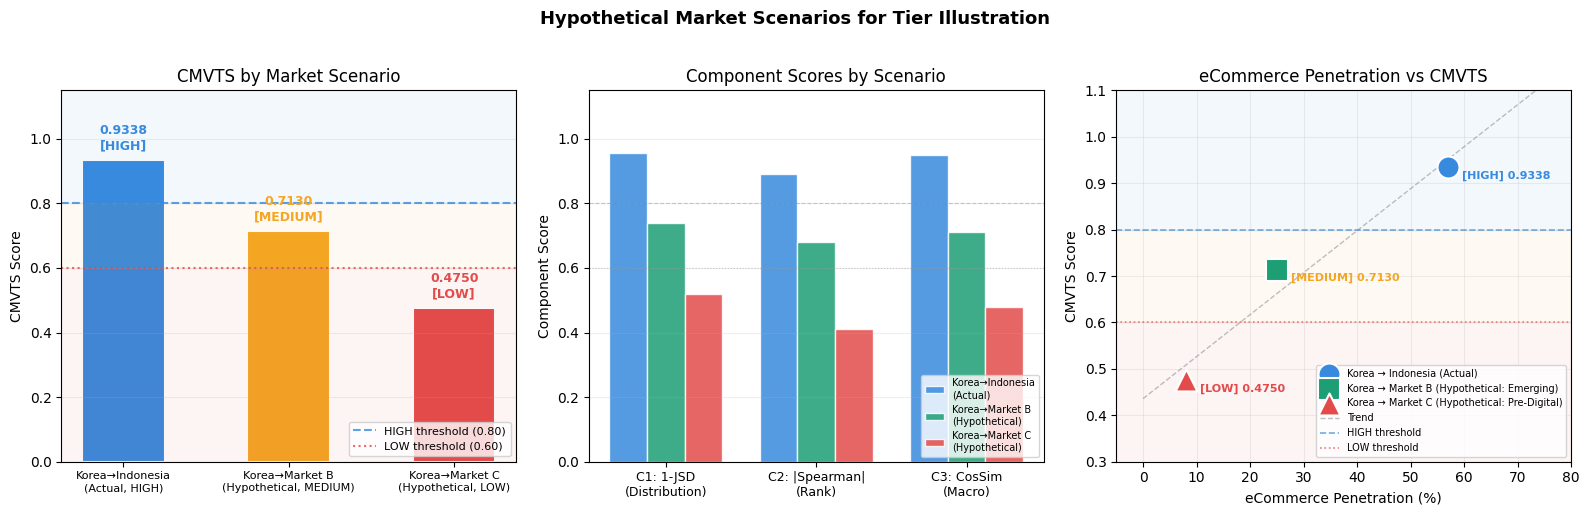

저장 완료: outputs/figures/04b_hypothetical_scenarios.png
저장 완료: outputs/tables/04c_hypothetical_scenarios.csv

[논문 삽입용 요약 테이블]
                                 market_pair    data_type  cmvts   tier                          decision
                  Korea → Indonesia (Actual)       Actual 0.9338   HIGH       Direct transfer recommended
   Korea → Market B (Hypothetical: Emerging) Hypothetical 0.7130 MEDIUM  Transfer with partial adjustment
Korea → Market C (Hypothetical: Pre-Digital) Hypothetical 0.4750    LOW Local data collection recommended


In [4]:
# %% [S1] 시나리오 정의
# ============================================================
# 가상 시장 Component 수치 산출 근거:
#
# Market B (MEDIUM — "Emerging Digital Market"):
#   실제 참조: 2018년 인도네시아 수준 / 현재 베트남 농촌 / 필리핀 지방
#   - 인터넷 보급률 ~45%  (인도네시아 2021: 72.9%)
#   - e커머스 보급률 ~25% (인도네시아 2021: 57%)
#   - C1(1-JSD): 0.74 — 카드/자산 변수 분포가 한국과 상당히 다름
#     → JSD 평균이 현재 0.044에서 ~0.26으로 상승한다고 가정
#   - C2(|ρ|): 0.68 — 변수 중요도 순위 일치도 중간
#     → 자산·카드 변수 순위는 유사하나 대출 변수 순위 역전
#   - C3(CosSim): 0.71 — e커머스 지표 부분 유사, 금융 인프라 격차
#
# Market C (LOW — "Pre-Digital Market"):
#   실제 참조: 미얀마, 캄보디아 농촌, 방글라데시 농촌
#   - 인터넷 보급률 ~20%
#   - e커머스 보급률 ~8%
#   - C1(1-JSD): 0.52 — 변수 분포 구조 자체가 한국과 크게 다름
#     → 대부분 변수에서 JSD > 0.4
#   - C2(|ρ|): 0.41 — 경제 발전 단계 차이로 변수 중요도 순위 불일치
#   - C3(CosSim): 0.48 — 디지털 인프라 지표 벡터 방향 크게 다름
# ============================================================

SCENARIOS = {
    'Korea → Indonesia\n(Actual)': {
        'c1': sim1_jsd,
        'c2': abs_rho,
        'c3': cos_sim,
        'color': '#378ADD',
        'marker': 'o',
        'note': 'Actual computation (AI-Hub + Statista)',
        'internet': 72.9,
        'smartphone': 72.1,
        'ecommerce': 57.0,
        'data_type': 'Actual',
    },
    'Korea → Market B\n(Hypothetical: Emerging)': {
        'c1': 0.74,
        'c2': 0.68,
        'c3': 0.71,
        'color': '#1D9E75',
        'marker': 's',
        'note': 'Hypothetical (internet ~45%, eComm ~25%)',
        'internet': 45.0,
        'smartphone': 40.0,
        'ecommerce': 25.0,
        'data_type': 'Hypothetical',
    },
    'Korea → Market C\n(Hypothetical: Pre-Digital)': {
        'c1': 0.52,
        'c2': 0.41,
        'c3': 0.48,
        'color': '#E24B4A',
        'marker': '^',
        'note': 'Hypothetical (internet ~20%, eComm ~8%)',
        'internet': 20.0,
        'smartphone': 18.0,
        'ecommerce': 8.0,
        'data_type': 'Hypothetical',
    },
}

# CMVTS 및 등급 계산
for name, s in SCENARIOS.items():
    s['cmvts'] = round(w1*s['c1'] + w2*s['c2'] + w3*s['c3'], 4)
    if s['cmvts'] >= 0.8:
        s['tier'] = 'HIGH'
        s['decision'] = 'Direct transfer recommended'
        s['tier_color'] = '#378ADD'
    elif s['cmvts'] >= 0.6:
        s['tier'] = 'MEDIUM'
        s['decision'] = 'Transfer with partial adjustment'
        s['tier_color'] = '#F4A623'
    else:
        s['tier'] = 'LOW'
        s['decision'] = 'Local data collection recommended'
        s['tier_color'] = '#E24B4A'

# %% [S2] 결과 출력
print("=" * 70)
print("  Hypothetical Market Scenarios for Tier Illustration")
print("=" * 70)
print(f"\n  {'Market Pair':<38} {'C1':>6} {'C2':>6} {'C3':>6} {'CMVTS':>7} {'Tier':>8}")
print(f"  {'-'*70}")
for name, s in SCENARIOS.items():
    label = name.replace('\n', ' ')
    print(f"  {label:<38} {s['c1']:>6.4f} {s['c2']:>6.4f} "
          f"{s['c3']:>6.4f} {s['cmvts']:>7.4f} {s['tier']:>8}")

print(f"\n  Tier thresholds: HIGH ≥ 0.80 | MEDIUM 0.60–0.79 | LOW < 0.60")
print("=" * 70)

print("\n  [시나리오별 상세]")
for name, s in SCENARIOS.items():
    label = name.replace('\n', ' ')
    print(f"\n  {label}")
    print(f"    C1 (1-JSD)     : {s['c1']:.4f} × {w1} = {w1*s['c1']:.4f}")
    print(f"    C2 (|Spearman|): {s['c2']:.4f} × {w2} = {w2*s['c2']:.4f}")
    print(f"    C3 (CosSim)    : {s['c3']:.4f} × {w3} = {w3*s['c3']:.4f}")
    print(f"    CMVTS = {s['cmvts']:.4f}  →  [{s['tier']}] {s['decision']}")

# %% [S3] 시각화 (논문용 Figure)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hypothetical Market Scenarios for Tier Illustration',
             fontsize=13, fontweight='bold', y=1.02)

labels_short = ['Korea→Indonesia\n(Actual, HIGH)',
                'Korea→Market B\n(Hypothetical, MEDIUM)',
                'Korea→Market C\n(Hypothetical, LOW)']
cmvts_vals  = [s['cmvts']     for s in SCENARIOS.values()]
tier_colors = [s['tier_color'] for s in SCENARIOS.values()]
c1_vals     = [s['c1'] for s in SCENARIOS.values()]
c2_vals     = [s['c2'] for s in SCENARIOS.values()]
c3_vals     = [s['c3'] for s in SCENARIOS.values()]
sc_colors   = [s['color'] for s in SCENARIOS.values()]

# ── Plot 1: CMVTS 비교 막대 ──
bars = axes[0].bar(range(3), cmvts_vals,
                   color=tier_colors, width=0.5,
                   edgecolor='white', linewidth=1.5)
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('CMVTS Score')
axes[0].set_title('CMVTS by Market Scenario')
axes[0].axhline(y=0.8, color='#378ADD', linestyle='--',
                lw=1.5, label='HIGH threshold (0.80)', alpha=0.8)
axes[0].axhline(y=0.6, color='#E24B4A', linestyle=':',
                lw=1.5, label='LOW threshold (0.60)', alpha=0.8)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(axis='y', alpha=0.2)

# 배경 색띠 (등급 구간 표시)
axes[0].axhspan(0.8, 1.15, alpha=0.06, color='#378ADD')
axes[0].axhspan(0.6, 0.8,  alpha=0.06, color='#F4A623')
axes[0].axhspan(0.0, 0.6,  alpha=0.06, color='#E24B4A')

for bar, val, s in zip(bars, cmvts_vals, SCENARIOS.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.025,
                 f"{val:.4f}\n[{s['tier']}]",
                 ha='center', va='bottom',
                 fontsize=9, fontweight='bold',
                 color=s['tier_color'])

# ── Plot 2: Component별 그룹 막대 ──
x = np.arange(3)
width = 0.25
comp_labels = ['C1: 1-JSD\n(Distribution)', 'C2: |Spearman|\n(Rank)', 'C3: CosSim\n(Macro)']
all_c = [c1_vals, c2_vals, c3_vals]
sc_labels_short = ['Korea→Indonesia\n(Actual)',
                   'Korea→Market B\n(Hypothetical)',
                   'Korea→Market C\n(Hypothetical)']

for i in range(3):
    vals = [all_c[j][i] for j in range(3)]
    axes[1].bar(x + (i-1)*width, vals, width,
                label=sc_labels_short[i],
                color=sc_colors[i], alpha=0.85, edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(comp_labels, fontsize=9)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Component Score')
axes[1].set_title('Component Scores by Scenario')
axes[1].legend(fontsize=7, loc='lower right')
axes[1].grid(axis='y', alpha=0.2)
axes[1].axhline(y=0.8, color='gray', linestyle='--', lw=0.8, alpha=0.4)
axes[1].axhline(y=0.6, color='gray', linestyle=':',  lw=0.8, alpha=0.4)

# ── Plot 3: e커머스 보급률 vs CMVTS 산점도 ──
for s_name, s in SCENARIOS.items():
    axes[2].scatter(s['ecommerce'], s['cmvts'],
                    s=250, color=s['color'],
                    marker=s['marker'], zorder=5,
                    label=s_name.replace('\n', ' '),
                    edgecolors='white', linewidths=1.5)
    tier_label = f"[{s['tier']}] {s['cmvts']:.4f}"
    axes[2].annotate(tier_label,
                     (s['ecommerce'], s['cmvts']),
                     textcoords='offset points',
                     xytext=(10, -8), fontsize=8,
                     color=s['tier_color'], fontweight='bold')

# 추세선
ec_vals  = [s['ecommerce'] for s in SCENARIOS.values()]
cm_vals  = [s['cmvts']     for s in SCENARIOS.values()]
z = np.polyfit(ec_vals, cm_vals, 1)
x_line = np.linspace(0, 75, 100)
axes[2].plot(x_line, np.polyval(z, x_line),
             color='gray', linestyle='--', lw=1, alpha=0.5,
             label='Trend')

axes[2].axhline(y=0.8, color='#378ADD', linestyle='--',
                lw=1.2, alpha=0.7, label='HIGH threshold')
axes[2].axhline(y=0.6, color='#E24B4A', linestyle=':',
                lw=1.2, alpha=0.7, label='LOW threshold')
axes[2].axhspan(0.8, 1.1, alpha=0.06, color='#378ADD')
axes[2].axhspan(0.6, 0.8, alpha=0.06, color='#F4A623')
axes[2].axhspan(0.0, 0.6, alpha=0.06, color='#E24B4A')
axes[2].set_xlabel('eCommerce Penetration (%)')
axes[2].set_ylabel('CMVTS Score')
axes[2].set_title('eCommerce Penetration vs CMVTS')
axes[2].legend(fontsize=7, loc='lower right')
axes[2].grid(alpha=0.2)
axes[2].set_xlim(-5, 80)
axes[2].set_ylim(0.3, 1.1)

plt.tight_layout()
plt.savefig('outputs/figures/04b_hypothetical_scenarios.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: outputs/figures/04b_hypothetical_scenarios.png")

# %% [S4] 논문용 테이블 저장
rows = []
for name, s in SCENARIOS.items():
    rows.append({
        'market_pair'        : name.replace('\n', ' '),
        'data_type'          : s['data_type'],
        'internet_pct'       : s['internet'],
        'smartphone_pct'     : s['smartphone'],
        'ecommerce_pct'      : s['ecommerce'],
        'component1_1mJSD'   : s['c1'],
        'component2_spearman': s['c2'],
        'component3_cossim'  : s['c3'],
        'cmvts'              : s['cmvts'],
        'tier'               : s['tier'],
        'decision'           : s['decision'],
        'note'               : s['note'],
    })

scenario_df = pd.DataFrame(rows)
scenario_df.to_csv('outputs/tables/04c_hypothetical_scenarios.csv',
                   index=False, encoding='utf-8-sig')
print("저장 완료: outputs/tables/04c_hypothetical_scenarios.csv")

print("\n[논문 삽입용 요약 테이블]")
print("=" * 70)
display_cols = ['market_pair', 'data_type', 'cmvts', 'tier', 'decision']
print(scenario_df[display_cols].to_string(index=False))
print("=" * 70)